In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')
file_dir = '/content/gdrive/My Drive/Re-Learn/Dicoding/Capstone/'

Mounted at /content/gdrive/


# Import Library

In [ ]:
# Library yang sering digunakan
import os, shutil
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm as tq

In [ ]:
# Libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

In [ ]:
# Libraries untuk pembangunan model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
# Mencetak versi TensorFlow yang sedang digunakan
print(tf.__version__)

2.18.0


# Data Loading

## Data Checking

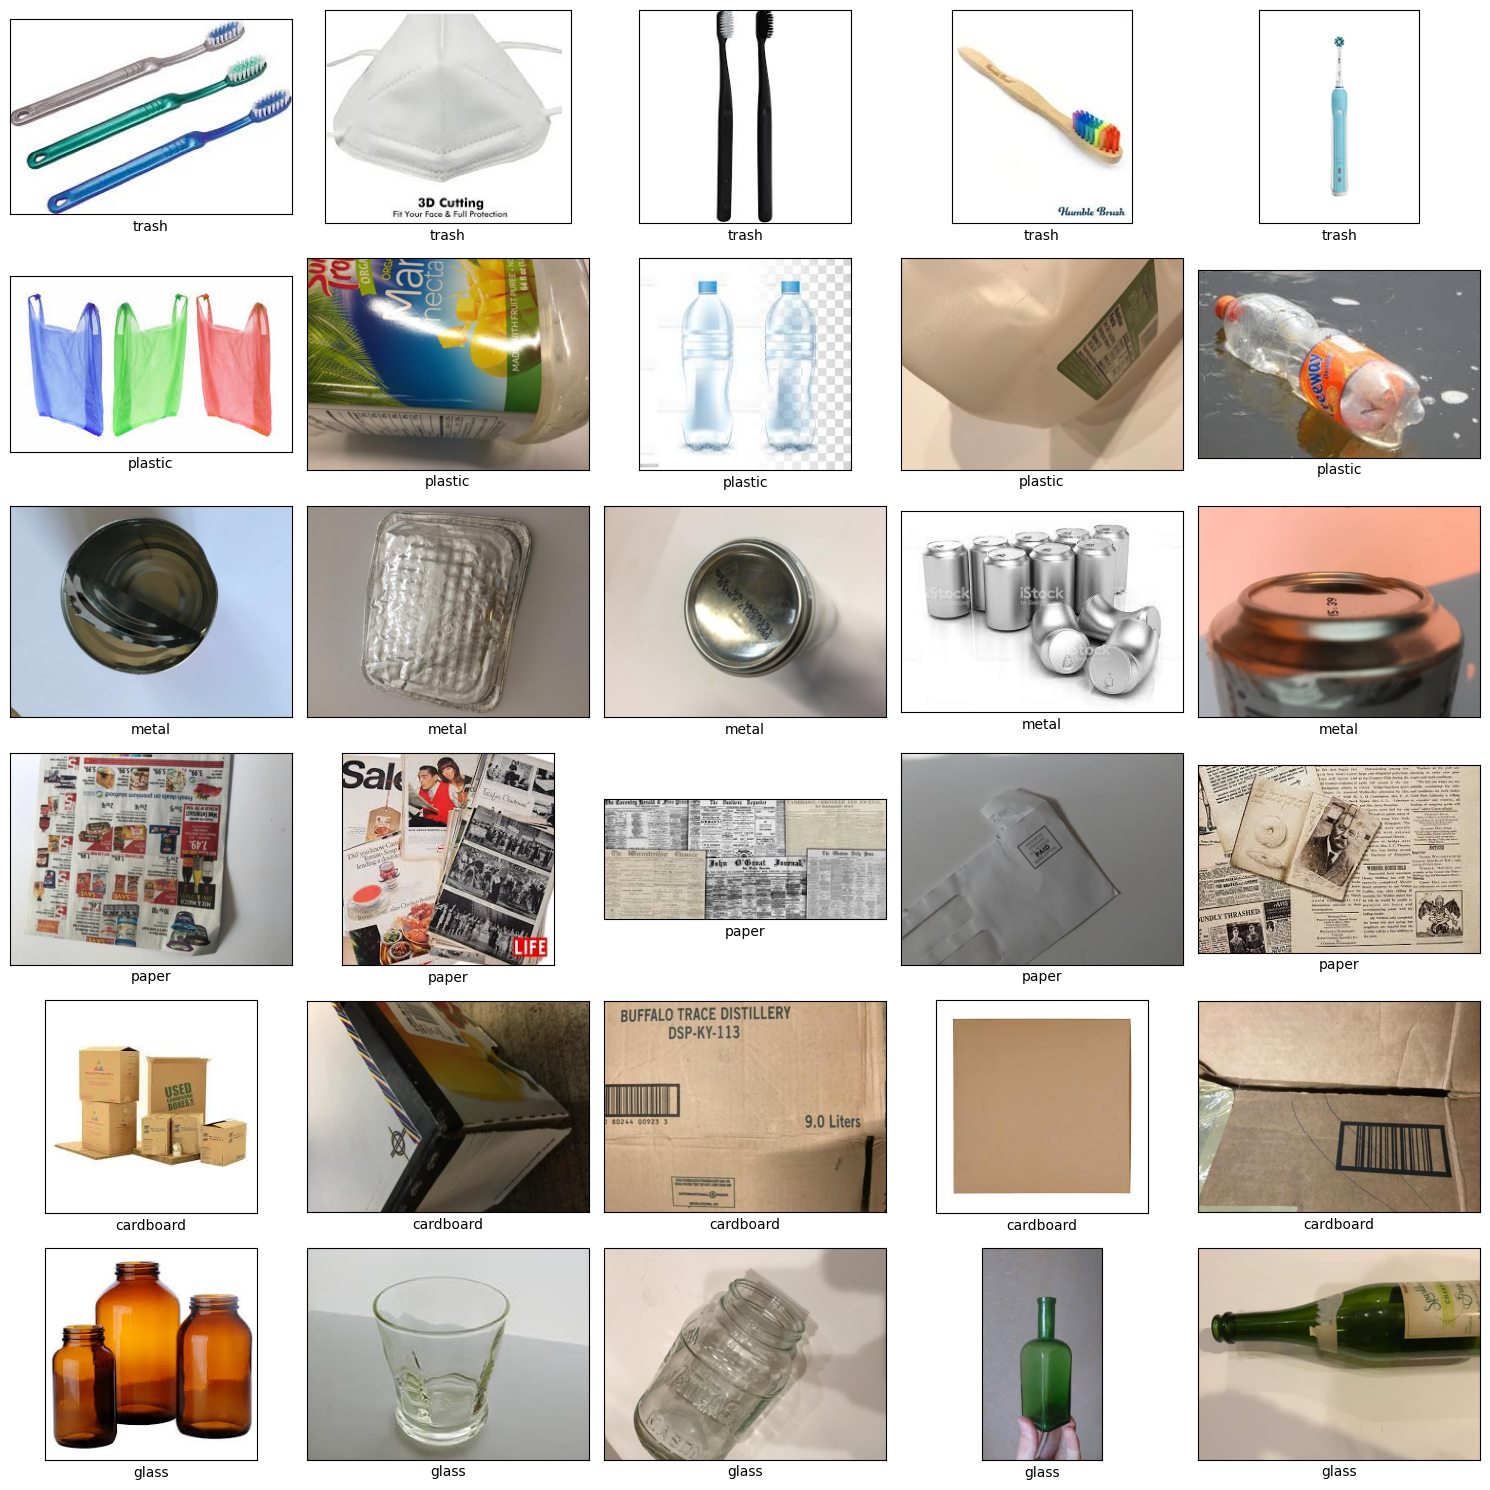

In [ ]:
# Membuat kamus yang menyimpan gambar untuk setiap kelas dalam data
trash_image = {}

# Tentukan path sumber train
path = file_dir + "dataset/"
# path_sub = os.path.join(path, "trashnet-resized")
path_sub = os.path.join(path, "trashmerged")
for i in os.listdir(path_sub):
    trash_image[i] = os.listdir(os.path.join(path_sub, i))

# Menampilkan secara acak 5 gambar di bawah setiap kelas dari data latih
fig, axs = plt.subplots(len(trash_image.keys()), 5, figsize=(15, 15))

for i, class_name in enumerate(os.listdir(path_sub)):
    images = np.random.choice(trash_image[class_name], 5, replace=False)

    # print(trash_image.keys())

    for j, image_name in enumerate(images):
        img_path = os.path.join(path_sub, class_name, image_name)
        img = Image.open(img_path) # .convert("L")  # Konversi menjadi skala keabuan
        axs[i, j].imshow(img)
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])


fig.tight_layout()

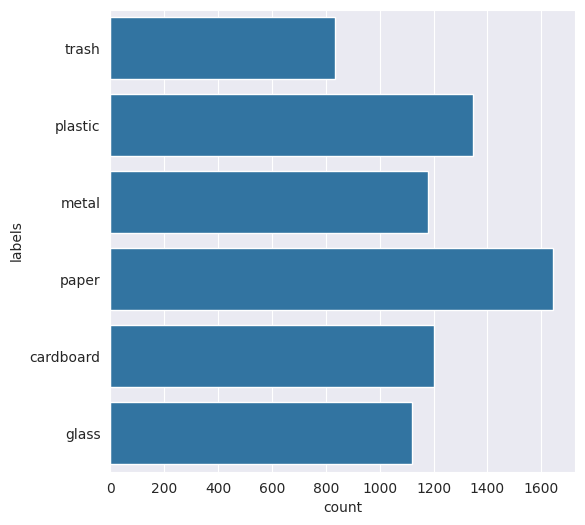

In [ ]:
# Definisikan path sumber
# trashnet_path = file_dir + "dataset/trashnet-resized/"
trashnet_path = file_dir + "dataset/trashmerged/"

# Buat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam data
file_name = []
labels = []
full_path = []

# Dapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai dataframe
for path, subdirs, files in os.walk(trashnet_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})

# Plot distribusi gambar di setiap kelas
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

# Data Augmentation

In [ ]:
# Membuat fungsi untuk melakukan rotasi berlawanan arah jarum jam
def anticlockwise_rotation(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    sudut = random.randint(0,180)
    return rotate(img, sudut)

# Membuat fungsi untuk melakukan rotasi searah jarum jam
def clockwise_rotation(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    sudut = random.randint(0,180)
    return rotate(img, -sudut)

# Membuat fungsi untuk membalik gambar secara vertikal dari atas ke bawah
def flip_up_down(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    return np.flipud(img)

# Membuat fungsi untuk memberikan efek peningkatan kecerahan pada gambar
def add_brightness(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    img = adjust_gamma(img, gamma=0.5,gain=1)
    return img

# Membuat fungsi untuk memberikan efek blur pada gambar
def blur_image(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    return cv2.GaussianBlur(img, (9,9),0)

# Membuat fungsi untuk memberikan efek pergeseran acak pada gambar
def sheared(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    transform = AffineTransform(shear=0.2)
    shear_image = warp(img, transform, mode="wrap")
    return shear_image

# Membuat fungsi untuk melakukan pergeseran melengkung pada gambar
def warp_shift(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    transform = AffineTransform(translation=(0,40))
    warp_image = warp(img, transform, mode="wrap")
    return warp_image

In [ ]:
# Membuat variabel transformasi yang akan menyimpan semua proses pra-pemrosesan yang telah dilakukan sebelumnya
transformations = {'rotate anticlockwise': anticlockwise_rotation,
                   'rotate clockwise': clockwise_rotation,
                   'warp shift': warp_shift,
                   'blurring image': blur_image,
                   'add brightness' : add_brightness,
                   'flip up down': flip_up_down,
                   'shear image': sheared
                  }

images_path = file_dir + "dataset/trashnet-resized/trash" # Path untuk gambar asli
augmented_path = file_dir + "dataset/trashnet-resized/trash" # Path untuk gambar yang sudah diaugmentasi
images = [] # Penyimpanan gambar yang telah melalui pra-pemrosesan

# Baca nama gambar dari folder dan tambahkan path ke dalam array "images"
for im in os.listdir(images_path):
    images.append(os.path.join(images_path,im))

# Jumlah gambar yang akan ditambahkan dengan hasil transformasi augmentasi, jumlahnya disesuaikan sesuai kebutuhan
# Variabel untuk melakukan iterasi sampai jumlah gambar yang ditentukan dalam images_to_generate
images_to_generate = 350
i = 1

while i <= images_to_generate:
    image=random.choice(images)
    try:
        original_image = io.imread(image)
        transformed_image = None
        n = 0      # Variabel untuk melakukan iterasi sampai jumlah transformasi yang akan diterapkan
        transformation_count = random.randint(1, len(transformations)) # Pilih jumlah transformasi acak yang akan diterapkan pada gambar

        while n <= transformation_count:
            key = random.choice(list(transformations)) # Secara acak memilih dan memanggil metode
            transformed_image = transformations[key](original_image)
            n = n + 1

        new_image_path = "%s/augmented_image_%s.jpg" %(augmented_path, i)
        transformed_image = img_as_ubyte(transformed_image)  # Mengonversi gambar ke format byte yang tidak ditandatangani, dengan nilai dalam [0, 255]
        cv2.imwrite(new_image_path, transformed_image)  # Simpan hasil transformasi augmentasi pada gambar ke path yang ditentukan
        i = i+1
    except ValueError as e:
        print('could not read the', image , ':', e, 'hence skipping it.')

# Data Splitting

In [ ]:
# Panggil variabel mypath yang menampung folder dataset gambar
# mypath = file_dir + 'dataset/trashnet-resized/'
mypath = file_dir + 'dataset/trashmerged/'

file_name = []
labels = []
full_path = []
for path, subdirs, files in os.walk(mypath):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

# Memasukkan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah dataframe agar rapi
df = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})
# Melihat jumlah data gambar pada masing-masing label
df.groupby(['labels']).size()

,0
labels,
cardboard,1201
glass,1121
metal,1179
paper,1644
plastic,1347
trash,834


In [ ]:
# Variabel yang digunakan pada pemisahan data ini di mana variabel x = data path dan y = data labels
X = df['path']
y = df['labels']

# Split dataset awal menjadi data train dan test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=300)

In [ ]:
# Menyatukan ke dalam masing-masing dataframe
df_tr = pd.DataFrame({'path':X_train,'labels':y_train,'set':'train'})
df_te = pd.DataFrame({'path':X_test,'labels':y_test,'set':'test'})

In [ ]:
# Gabungkan DataFrame df_tr dan df_te
df_all = pd.concat([df_tr, df_te], ignore_index=True)

print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')
print('===================================================== \n')

# Cek sampel data
print(df_all.sample(5))

# Memanggil dataset asli yang berisi keseluruhan data gambar yang sesuai dengan labelnya
datasource_path = "dataset/trashmerged/"
# Membuat variabel Dataset, tempat menampung data yang telah dilakukan pembagian data training dan testing
dataset_path = "dataset-final/"


set    labels   
test   cardboard     258
       glass         218
       metal         232
       paper         310
       plastic       279
       trash         169
train  cardboard     943
       glass         903
       metal         947
       paper        1334
       plastic      1068
       trash         665
dtype: int64 


                                                   path     labels    set
7261  /content/gdrive/My Drive/Re-Learn/Dicoding/Cap...  cardboard   test
1659  /content/gdrive/My Drive/Re-Learn/Dicoding/Cap...      paper  train
3029  /content/gdrive/My Drive/Re-Learn/Dicoding/Cap...      paper  train
1400  /content/gdrive/My Drive/Re-Learn/Dicoding/Cap...      metal  train
4483  /content/gdrive/My Drive/Re-Learn/Dicoding/Cap...      metal  train


In [ ]:
for index, row in tq(df_all.iterrows()):
    # Deteksi filepath
    file_path = row['path']
    if os.path.exists(file_path) == False:
            file_path = os.path.join(datasource_path,row['labels'],row['image'].split('.')[0])

    # Buat direktori tujuan folder
    if os.path.exists(os.path.join(dataset_path, row['set'], row['labels'])) == False:
        os.makedirs(os.path.join(dataset_path, row['set'], row['labels']))

    # Tentukan tujuan file
    destination_file_name = file_path.split('/')[-1]
    file_dest = os.path.join(dataset_path, row['set'], row['labels'], destination_file_name)

    # Salin file dari sumber ke tujuan
    if os.path.exists(file_dest) == False:
        shutil.copy2(file_path, file_dest)

0it [00:00, ?it/s]

# Image Data Generator

In [ ]:
def count_set(DIR, splitset, label):
    splitset_label = os.path.join(DIR + label)
    print("Total number of {0} images in {1}ing set: {2}".format(label, splitset, len(os.listdir(splitset_label))))
    return splitset_label

In [ ]:
# Definisikan direktori training dan test
TRAIN_DIR = "dataset-final/train/"
TEST_DIR = "dataset-final/test/"

train_cardboard = count_set(TRAIN_DIR, 'train', 'cardboard')
train_glass = count_set(TRAIN_DIR, 'train', 'glass')
train_metal = count_set(TRAIN_DIR, 'train', 'metal')
train_paper = count_set(TRAIN_DIR, 'train', 'paper')
train_plastic = count_set(TRAIN_DIR, 'train', 'plastic')
train_trash = count_set(TRAIN_DIR, 'train', 'trash')
print('\n')
count_set(TEST_DIR, 'test', 'cardboard')
count_set(TEST_DIR, 'test', 'glass')
count_set(TEST_DIR, 'test', 'metal')
count_set(TEST_DIR, 'test', 'paper')
count_set(TEST_DIR, 'test', 'plastic')
count_set(TEST_DIR, 'test', 'trash')

Total number of cardboard images in training set: 943
Total number of glass images in training set: 903
Total number of metal images in training set: 947
Total number of paper images in training set: 1334
Total number of plastic images in training set: 1068
Total number of trash images in training set: 665


Total number of cardboard images in testing set: 258
Total number of glass images in testing set: 218
Total number of metal images in testing set: 232
Total number of paper images in testing set: 310
Total number of plastic images in testing set: 279
Total number of trash images in testing set: 169


'dataset-final/test/trash'

In [ ]:
# Buat objek ImageDataGenerator yang menormalkan gambar
datagen = ImageDataGenerator(rescale=1/255.,
                             validation_split = 0.2)
test_datagen = ImageDataGenerator(rescale=1. / 255)

train_generator = datagen.flow_from_directory(TRAIN_DIR,
                                              batch_size=2,
                                              target_size=(150,150),
                                              color_mode="grayscale",
                                              class_mode='binary',
                                              subset='training',
                                              shuffle=True)

validation_generator = datagen.flow_from_directory(TRAIN_DIR,
                                                   batch_size=2,
                                                   target_size=(150,150),
                                                   color_mode="grayscale",
                                                   class_mode='binary',
                                                   subset='validation',
                                                   shuffle=False)

test_generator = test_datagen.flow_from_directory(TEST_DIR,
                                                  batch_size=2,
                                                  target_size=(150,150),
                                                  color_mode="grayscale",
                                                  class_mode='binary',
                                                  shuffle=False)

Found 4691 images belonging to 6 classes.
Found 1169 images belonging to 6 classes.
Found 1466 images belonging to 6 classes.


# Pembangunan Model dengan Beberapa Skema Parameter Tuning

In [ ]:
# tf.keras.backend.clear_session()

####################### Init sequential model ##################################
model_1 = Sequential()

# ######################### Input layer with Fully Connected Layer ################################
# 1st Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(150,150,1)))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))

# 2nd Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(Conv2D(32, (4, 4),padding='same', activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))

# 3rd Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(Conv2D(32, (7, 7), padding='same', activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))

# Flatten layer
model_1.add(Flatten())
# 1nd Dense Layer
model_1.add(Dense(128, activation = 'relu'))
# 1nd Dropout Layer
model_1.add(Dropout(0.5))
# 2nd Dense Layer
model_1.add(Dense(64, activation = 'relu'))
# 2nd Dropout Layer
model_1.add(Dropout(0.3))

# Final Dense layer => For output prediction 1 mean (binary class in dataset), sigmoid for binary cases
model_1.add(Dense(6, activation='softmax'))
######################### Fully Connected Layer ################################

######################### Compile Model ################################
model_1.compile(optimizer=tf.keras.optimizers.RMSprop(),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

# Summary of the Model Architecture
print(model_1.summary())

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 32)     │        50,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,327,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,403,206 (5.35 MB)

 Trainable params: 1,403,014 (5.35 MB)

 Non-trainable params: 192 (768.00 B)

None


In [ ]:
count_cardboard, count_glass, count_metal, count_paper, count_plastic, count_trash = len(os.listdir(train_cardboard)), len(os.listdir(train_glass)), len(os.listdir(train_metal)), len(os.listdir(train_paper)), len(os.listdir(train_plastic)), len(os.listdir(train_trash))
count_train_all = count_cardboard + count_glass + count_metal + count_paper + count_plastic + count_trash
weight_0 = (1 / count_cardboard) * count_train_all / 2.0
weight_1 = (1 / count_glass) * count_train_all / 2.0
weight_2 = (1 / count_metal) * count_train_all / 2.0
weight_3 = (1 / count_paper) * count_train_all / 2.0
weight_4 = (1 / count_plastic) * count_train_all / 2.0
weight_5 = (1 / count_trash) * count_train_all / 2.0

class_weights = {0 : weight_0, 1 : weight_1, 2 : weight_2, 3 : weight_3, 4 : weight_4, 5 : weight_5}

%time

# Fitting / training model
history_1 = model_1.fit(train_generator,
                        epochs=30,
                        batch_size=2,
                        validation_data=validation_generator,
                        class_weight = class_weights)

CPU times: user 3 µs, sys: 1 µs, total: 4 µs
Wall time: 6.91 µs
Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2346/2346 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - accuracy: 0.2070 - loss: 11.7653 - val_accuracy: 0.2421 - val_loss: 1.7331
Epoch 2/30
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 30s 6ms/step - accuracy: 0.2104 - loss: 5.5376 - val_accuracy: 0.1660 - val_loss: 1.7607
Epoch 3/30
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.2098 - loss: 5.6210 - val_accuracy: 0.1916 - val_loss: 1.8266
Epoch 4/30
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.2257 - loss: 5.5528 - val_accuracy: 0.1292 - val_loss: 1.8595
Epoch 5/30
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.1973 - loss: 5.4863 - val_accuracy: 0.2293 - val_loss: 1.8062
Epoch 6/30
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.2439 - loss: 5.5792 - val_accuracy: 0.2643 - val_loss: 1.9207
Epoch 7/30
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.2468 - loss: 5.4736 - val_accuracy: 0.2703 - val_loss: 1.8860
Epoch 8/30
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.2827 - loss: 5.2860 - va

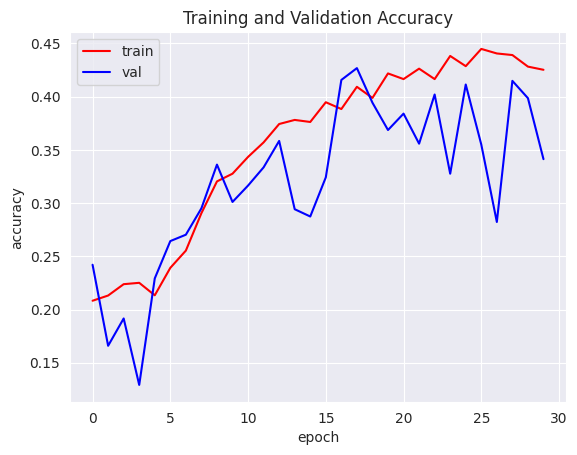

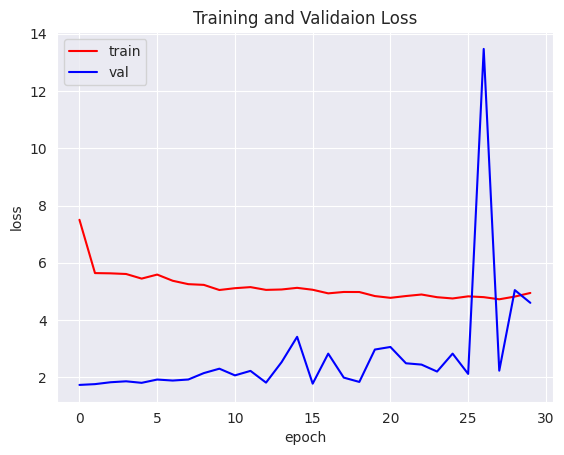

In [ ]:
acc = history_1.history['accuracy']
val_acc = history_1.history['val_accuracy']
loss = history_1.history['loss']
val_loss = history_1.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.show()

In [ ]:
test_generator.reset()

result = model_1.predict(test_generator,verbose=0)
preds_1 = np.argmax(result, axis = 1)
preds_1 = preds_1.copy()

y_true = test_generator.classes

<Axes: >

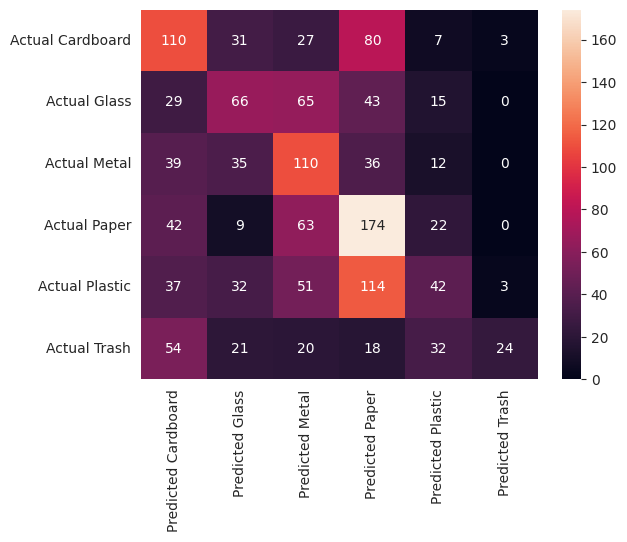

In [ ]:
cm = pd.DataFrame(data=confusion_matrix(y_true, preds_1,
                                        labels=[0, 1, 2, 3, 4, 5]), index=["Actual Cardboard", "Actual Glass", "Actual Metal", "Actual Paper", "Actual Plastic", "Actual Trash"],
                                        columns=["Predicted Cardboard", "Predicted Glass", "Predicted Metal", "Predicted Paper", "Predicted Plastic", "Predicted Trash"])
sns.heatmap(cm,annot=True,fmt="d")

In [ ]:
print(classification_report(y_true=y_true,
                            y_pred=preds_1,
                            target_names =['Cardboard', 'Glass', 'Metal', 'paper', 'Plastic', 'Trash'], digits=4))

              precision    recall  f1-score   support

   Cardboard     0.3537    0.4264    0.3866       258
       Glass     0.3402    0.3028    0.3204       218
       Metal     0.3274    0.4741    0.3873       232
       paper     0.3742    0.5613    0.4490       310
     Plastic     0.3231    0.1505    0.2054       279
       Trash     0.8000    0.1420    0.2412       169

    accuracy                         0.3588      1466
   macro avg     0.4198    0.3428    0.3317      1466
weighted avg     0.3975    0.3588    0.3388      1466

